实验介绍：本实验将对股票交易中的双均线策略和配对交易策略的算法进行模拟实现，与此同时还运用主成分分析、随机森林等特征工程方法，利用LSTM模型对股票数据进行预测，并且凭已训练的模型为交易提供参考，从而实现基于预测的交易策略。

In [3]:
import tushare as ts
import talib
import mplfinance as mpf
import matplotlib.pyplot as plt
import pandas as pd
import ffn

In [4]:
import numpy as np

In [5]:
ts.set_token('8f1863b6da065bd9441963ccd45970f934412722461a017b0007de14')
ts_pro = ts.pro_api()

以000001.SZ，2024年1月至11月数据为例展示股票数据的获取与K线图的绘制

In [7]:
A_data = ts_pro.daily(ts_code='000001.SZ',
                   start_date = '20240101',
                   end_date ='20241124')
print(A_data) #获取日线行情

       ts_code trade_date   open   high    low  close  pre_close  change  \
0    000001.SZ   20241122  11.59  11.61  11.28  11.28      11.59   -0.31   
1    000001.SZ   20241121  11.62  11.65  11.56  11.59      11.64   -0.05   
2    000001.SZ   20241120  11.67  11.75  11.61  11.64      11.68   -0.04   
3    000001.SZ   20241119  11.75  11.96  11.55  11.68      11.75   -0.07   
4    000001.SZ   20241118  11.63  12.04  11.62  11.75      11.44    0.31   
..         ...        ...    ...    ...    ...    ...        ...     ...   
210  000001.SZ   20240108   9.23   9.30   9.11   9.15       9.27   -0.12   
211  000001.SZ   20240105   9.10   9.44   9.07   9.27       9.11    0.16   
212  000001.SZ   20240104   9.19   9.19   9.08   9.11       9.20   -0.09   
213  000001.SZ   20240103   9.19   9.22   9.15   9.20       9.21   -0.01   
214  000001.SZ   20240102   9.39   9.42   9.21   9.21       9.39   -0.18   

     pct_chg         vol       amount  
0    -2.6747  1625317.44  1858071.592  
1    -0

In [8]:
A_data = pd.DataFrame(A_data)
A_data = A_data.reindex(index=A_data.index[::-1])
A_data = A_data.reset_index(drop=True)
A_data = A_data.loc[:, ['trade_date', 'open', 'high', 'low', 'close', 'vol']]
A_data.rename(columns={
        'trade_date': 'Date',
        'open': 'Open',
        'high': 'High',
        'low': 'Low',
        'close': 'Close',
        'vol': 'Volume'
    },inplace=True)       # 重定义列名，方便统一规范操作。
A_data['Date'] = pd.to_datetime(A_data['Date'])  # 转换日期列的格式，便于作图
A_data.set_index(['Date'], inplace=True)  # 将日期列作为行索引

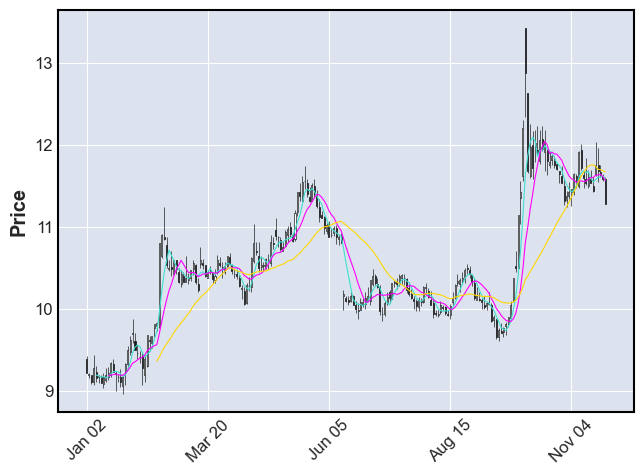

In [9]:
mpf.plot(A_data, type='candle', mav=(5, 10, 30)) #做K线图，画出5，10，30日均线

# 1.双均线策略的实现（以000001.SZ为例）

In [10]:
df = ts_pro.daily(ts_code='000001.SZ',
                   start_date = '20240101',
                   end_date ='20241124')
df.drop(['ts_code','open','high','low','change','pct_chg','vol','amount','pre_close'],axis=1,inplace=True)
df.dropna(inplace=True)
df = df.reindex(index=df.index[::-1])
df = df.reset_index(drop=True)
df['ma5']=df['close'].rolling(5).mean()
df['ma10']=df['close'].rolling(10).mean()
df['signal'] = np.where(np.logical_and(df['ma5'].shift(1) >= df['ma10'].shift(1) , df['ma5'] <= df['ma10']), -1,\
                        np.where(np.logical_and(df['ma5'].shift(1) <= df['ma10'].shift(1), df['ma5'] >= df['ma10']), 1 , 0))

#找到5日均线向上穿过10日均线的点为买入信号，向下穿过为卖出信号

In [184]:
capital = 100000 #初始总资产
position = 0 #初始持有股数
cash = 100000 #初始总现金
df['position'] = position
df['cash'] = cash
df['capital'] = capital

In [185]:
for i in range(len(df)):
    signal = df.iloc[i]['signal']
    price = df.iloc[i]['close']
    date = df.iloc[i]['trade_date']

    if signal==1: #买入信号
        buy = int(capital/price/100)*40 #计算购买的股数
        position += buy
        cash -= price*buy
        capital = cash + price*position
        print("买入日期：{}，买入价格：{}，买入数量：{}，当前资产：{}，当前持仓{}".format(date,price,buy,capital,position))

        df.iloc[i,df.columns.get_loc('capital')] = capital
        df.iloc[i,df.columns.get_loc('position')] = position
        df.iloc[i,df.columns.get_loc('cash')] = cash
    elif signal==0:
        capital = cash + price*position
        df.iloc[i,df.columns.get_loc('capital')] = capital
        df.iloc[i,df.columns.get_loc('position')] = position
        df.iloc[i,df.columns.get_loc('cash')] = cash
    elif signal==-1:
        sell = int(position*0.5)
        position = position - sell
        cash += sell*price
        capital = position*price + cash
        print("卖出日期：{}，卖出价格：{}，卖出数量：{}，当前资产：{}，当前持仓{}".format(date,price,sell,capital,position))

        df.iloc[i,df.columns.get_loc('capital')] = capital
        df.iloc[i,df.columns.get_loc('position')] = position
        df.iloc[i,df.columns.get_loc('cash')] = cash
    else:
        pass
print("最终总资产：{}".format(cash+position*df.iloc[-1]['close']))

买入日期：20240116，买入价格：9.34，买入数量：4280，当前资产：100000.0，当前持仓4280
卖出日期：20240123，卖出价格：9.16，卖出数量：2140，当前资产：99229.6，当前持仓2140
买入日期：20240125，买入价格：9.5，买入数量：4160，当前资产：99957.20000000001，当前持仓6300
卖出日期：20240205，卖出价格：9.38，卖出数量：3150，当前资产：99201.20000000001，当前持仓3150
买入日期：20240219，买入价格：9.81，买入数量：4080，当前资产：100555.70000000001，当前持仓7230
卖出日期：20240304，卖出价格：10.33，卖出数量：3615，当前资产：104315.3，当前持仓3615
买入日期：20240314，买入价格：10.23，买入数量：4040，当前资产：103953.80000000002，当前持仓7655
卖出日期：20240319，卖出价格：10.4，卖出数量：3827，当前资产：105255.15000000001，当前持仓3828
买入日期：20240320，买入价格：10.45，买入数量：4000，当前资产：105446.54999999999，当前持仓7828
卖出日期：20240325，卖出价格：10.4，卖出数量：3914，当前资产：105055.15，当前持仓3914
买入日期：20240326，买入价格：10.6，买入数量：3960，当前资产：105837.95，当前持仓7874
卖出日期：20240328，卖出价格：10.49，卖出数量：3937，当前资产：104971.81，当前持仓3937
买入日期：20240329，买入价格：10.52，买入数量：3960，当前资产：105089.92000000001，当前持仓7897
卖出日期：20240409，卖出价格：10.4，卖出数量：3948，当前资产：104142.28，当前持仓3949
买入日期：20240418，买入价格：10.8，买入数量：3880，当前资产：105721.88000000002，当前持仓7829
卖出日期：20240529，卖出价格：11.26，卖出数量：3914，当前资产：109323.22，当前持仓3915
买

C:\Users\13750\AppData\Local\Temp\ipykernel_23472\2634675361.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '60024.8' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.iloc[i,df.columns.get_loc('cash')] = cash
C:\Users\13750\AppData\Local\Temp\ipykernel_23472\2634675361.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '99529.20000000001' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.iloc[i,df.columns.get_loc('capital')] = capital


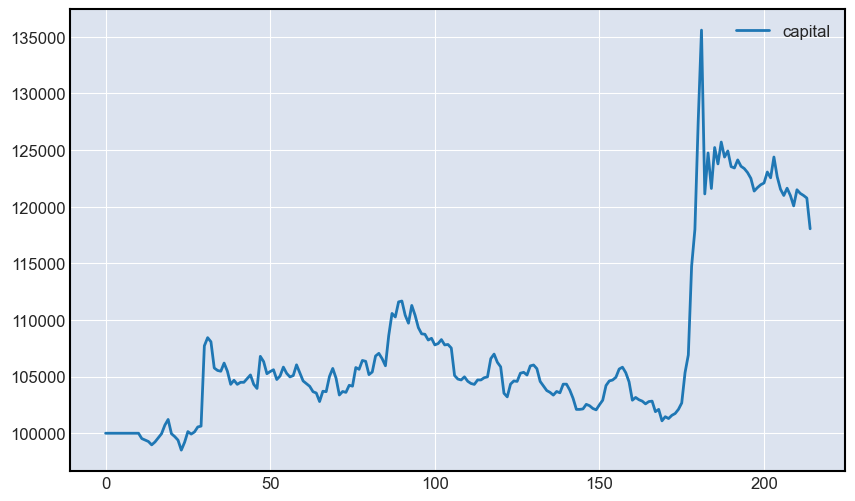

In [186]:
plt.figure(figsize=(10,6))
plt.plot(df['capital'],label='capital')
plt.legend()
plt.show() #将资产值可视化

# 2.LSTM预测下的交易实现

In [13]:
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM,Bidirectional

In [14]:
from sklearn.model_selection import train_test_split

In [32]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

In [84]:
df1 = ts_pro.daily(ts_code='000001.SZ',
                   start_date = '20180101',
                   end_date ='20231231')
df1 = pd.DataFrame(df1)
df1 = df1.reindex(index=df1.index[::-1])
df1 = df1.reset_index(drop=True)
print(df1) #获取日线行情

        ts_code trade_date   open   high    low  close  pre_close  change  \
0     000001.SZ   20180102  13.35  13.93  13.32  13.70      13.30    0.40   
1     000001.SZ   20180103  13.73  13.86  13.20  13.33      13.70   -0.37   
2     000001.SZ   20180104  13.32  13.37  13.13  13.25      13.33   -0.08   
3     000001.SZ   20180105  13.21  13.35  13.15  13.30      13.25    0.05   
4     000001.SZ   20180108  13.25  13.29  12.86  12.96      13.30   -0.34   
...         ...        ...    ...    ...    ...    ...        ...     ...   
1452  000001.SZ   20231225   9.18   9.20   9.14   9.19       9.20   -0.01   
1453  000001.SZ   20231226   9.19   9.20   9.07   9.10       9.19   -0.09   
1454  000001.SZ   20231227   9.10   9.13   9.02   9.12       9.10    0.02   
1455  000001.SZ   20231228   9.11   9.47   9.08   9.45       9.12    0.33   
1456  000001.SZ   20231229   9.42   9.48   9.35   9.39       9.45   -0.06   

      pct_chg         vol       amount  
0      3.0100  2081592.55  2856543

In [85]:
clo = df['close'].values

In [86]:
clo = np.reshape(clo, newshape=-1)

In [23]:
#以12天为一个滑动窗口，预测第13天的股价

In [87]:
X = []
label = []
win_len = 12

for i in range(len(clo)-win_len-1):
    X.append(clo[i:i + win_len])
    label.append(clo[i + win_len])
    
X = np.array(X)
label = np.array(label)

X_train, X_valid, y_train, y_valid = train_test_split(X, label, test_size=0.2)

In [89]:
model = Sequential()
model.add(LSTM(units= 80, activation='relu', input_shape=(X_train.shape[1],1)))
model.add(Dense(units=1))
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 80)             │        26,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,321 (102.82 KB)

 Trainable params: 26,321 (102.82 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
model.compile(optimizer=tf.keras.optimizers.Adam(0.001),loss='mae')

In [ ]:
history = model.fit(X_train, y_train, batch_size=72, epochs=200, validation_data=(X_valid,y_valid),validation_freq=1)
model.summary()

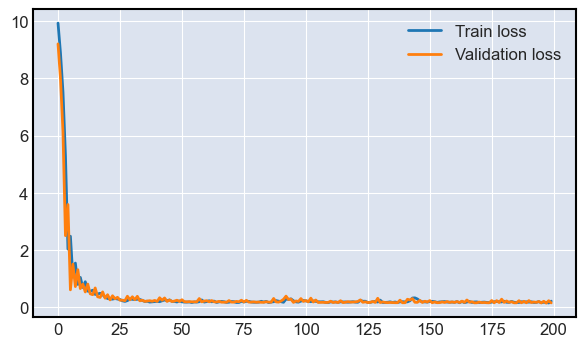

In [92]:
plt.figure(figsize=(7,4), dpi=100)
plt.plot(history.history['loss']  ,label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.show()

### 用已经训练的LSTM模型对2024年股票策略提供参考

In [93]:
df2 = ts_pro.daily(ts_code='000001.SZ',
                   start_date = '20240101',
                   end_date ='20241129')
df2 = pd.DataFrame(df2)
df2 = df2.reindex(index=df2.index[::-1])
df2 = df2.reset_index(drop=True)
print(df2) #获取日线行情

       ts_code trade_date   open   high    low  close  pre_close  change  \
0    000001.SZ   20240102   9.39   9.42   9.21   9.21       9.39   -0.18   
1    000001.SZ   20240103   9.19   9.22   9.15   9.20       9.21   -0.01   
2    000001.SZ   20240104   9.19   9.19   9.08   9.11       9.20   -0.09   
3    000001.SZ   20240105   9.10   9.44   9.07   9.27       9.11    0.16   
4    000001.SZ   20240108   9.23   9.30   9.11   9.15       9.27   -0.12   
..         ...        ...    ...    ...    ...    ...        ...     ...   
215  000001.SZ   20241125  11.28  11.34  11.14  11.18      11.28   -0.10   
216  000001.SZ   20241126  11.18  11.31  11.14  11.27      11.18    0.09   
217  000001.SZ   20241127  11.24  11.39  11.15  11.39      11.27    0.12   
218  000001.SZ   20241128  11.39  11.42  11.32  11.34      11.39   -0.05   
219  000001.SZ   20241129  11.37  11.46  11.34  11.38      11.34    0.04   

     pct_chg         vol       amount  
0    -1.9169  1158366.45  1075742.252  
1    -0

In [77]:
new_clo = df2['close'].values
new_clo = np.reshape(new_clo, newshape=-1)

In [96]:
pre_X = []
for i in range(len(new_clo)-win_len-1):
    pre_X.append(new_clo[i:i + win_len])
pre_X = np.array(pre_X)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


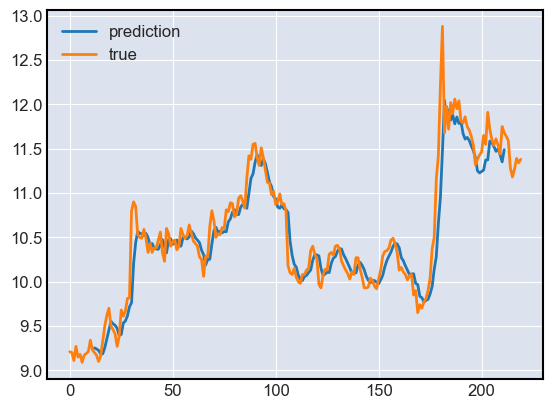

In [98]:
prediction = model.predict(pre_X[:200])
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(range(12, 12+len(prediction)), prediction)
ax.plot(range(len(new_clo)), new_clo)
ax.legend(['prediction','true'])
plt.show()

In [106]:
df3 = df2[['trade_date', 'close']]

In [116]:
all_pre = np.hstack((np.array(df3['close'])[0:12],np.reshape(prediction, newshape=-1)))
all_pre = pd.DataFrame(all_pre)

In [121]:
date_frame = df3['trade_date'][0:212]

In [123]:
close_frame = df3['close'][0:212]

In [129]:
df4 = pd.concat([date_frame,close_frame,all_pre], axis=1)
df4.rename(columns={0:'predict'},inplace=True)
df4

,trade_date,close,predict
0,20240102,9.21,9.210000
1,20240103,9.20,9.200000
2,20240104,9.11,9.110000
3,20240105,9.27,9.270000
4,20240108,9.15,9.150000
...,...,...,...
207,20241113,11.61,11.470104
208,20241114,11.54,11.496218
209,20241115,11.44,11.431400
210,20241118,11.75,11.350988


In [190]:
capital = 100000
cash = 100000
position = 0
df4['position'] = position
df4['cash'] = cash
df4['capital'] = capital

In [191]:
for i in range(0,len(df4)-1):
    price = df4.iloc[i]['close']
    date = df4.iloc[i]['trade_date']

    if df4.iloc[i+1]['predict']/df4.iloc[i]['predict'] > 1 and df4.iloc[i+1]['predict']/df4.iloc[i]['predict'] < 1.017:
        buy = int(cash/price/100)*40 #计算购买的股数
        position += buy
        cash -= price*buy
        capital = cash + price*position
        print("买入日期：{}，买入价格：{}，买入数量：{}，当前资产：{}，当前持仓：{}".format(date,price,buy,capital,position))
        df4.iloc[i,df4.columns.get_loc('capital')] = capital
        df4.iloc[i,df4.columns.get_loc('position')] = position
        df4.iloc[i,df4.columns.get_loc('cash')] = cash
        
    elif df4.iloc[i+1]['predict']/df4.iloc[i]['predict'] >= 1.017:
        buy = int(cash/price/100)*100 #计算购买的股数
        position += buy
        cash -= price*buy
        capital = cash + price*position
        print("买入日期：{}，买入价格：{}，买入数量：{}，当前资产：{}，当前持仓：{}".format(date,price,buy,capital,position))
        df4.iloc[i,df4.columns.get_loc('capital')] = capital
        df4.iloc[i,df4.columns.get_loc('position')] = position
        df4.iloc[i,df4.columns.get_loc('cash')] = cash
            
    elif df4.iloc[i+1]['predict']/df4.iloc[i]['predict'] <= 1 and df4.iloc[i+1]['predict']/df4.iloc[i]['predict'] > 0.99:
        sell = int(position*0.5)
        position = position - sell
        cash += sell*price
        capital = position*price + cash        
        print("卖出日期：{}，卖出价格：{}，卖出数量：{}，当前资产：{}，当前持仓：{}".format(date,price,sell,capital,position))
        
        df4.iloc[i,df4.columns.get_loc('capital')] = capital
        df4.iloc[i,df4.columns.get_loc('position')] = position
        df4.iloc[i,df4.columns.get_loc('cash')] = cash

    elif df4.iloc[i+1]['predict']/df4.iloc[i]['predict'] <= 0.99:
        sell = position
        position = position - sell
        cash += sell*price
        capital = position*price + cash        
        print("卖出日期：{}，卖出价格：{}，卖出数量：{}，当前资产：{}，当前持仓：{}".format(date,price,sell,capital,position))
        
        df4.iloc[i,df4.columns.get_loc('capital')] = capital
        df4.iloc[i,df4.columns.get_loc('position')] = position
        df4.iloc[i,df4.columns.get_loc('cash')] = cash

    else:
        capital = cash + price*position
        df4.iloc[i,df4.columns.get_loc('capital')] = capital
        df4.iloc[i,df4.columns.get_loc('position')] = position
        df4.iloc[i,df4.columns.get_loc('cash')] = cash
print("最终总资产：{}".format(cash+position*df4.iloc[-1]['close']))
df4.iloc[-1,df4.columns.get_loc('capital')] = cash+position*df4.iloc[-1]['close']

卖出日期：20240102，卖出价格：9.21，卖出数量：0，当前资产：100000.0，当前持仓：0
卖出日期：20240103，卖出价格：9.2，卖出数量：0，当前资产：100000.0，当前持仓：0
买入日期：20240104，买入价格：9.11，买入数量：10900，当前资产：100000.0，当前持仓：10900
卖出日期：20240105，卖出价格：9.27，卖出数量：10900，当前资产：101744.0，当前持仓：0
买入日期：20240108，买入价格：9.15，买入数量：4440，当前资产：101744.0，当前持仓：4440
卖出日期：20240109，卖出价格：9.18，卖出数量：2220，当前资产：101877.20000000001，当前持仓：2220
买入日期：20240110，买入价格：9.09，买入数量：3560，当前资产：101677.40000000001，当前持仓：5780
买入日期：20240111，买入价格：9.17，买入数量：2120，当前资产：102139.80000000002，当前持仓：7900
买入日期：20240112，买入价格：9.19，买入数量：1280，当前资产：102297.80000000002，当前持仓：9180
买入日期：20240115，买入价格：9.21，买入数量：760，当前资产：102481.40000000002，当前持仓：9940
卖出日期：20240116，卖出价格：9.34，卖出数量：9940，当前资产：103773.60000000002，当前持仓：0
买入日期：20240117，买入价格：9.23，买入数量：4480，当前资产：103773.60000000002，当前持仓：4480
卖出日期：20240118，卖出价格：9.2，卖出数量：2240，当前资产：103639.20000000001，当前持仓：2240
卖出日期：20240119，卖出价格：9.17，卖出数量：1120，当前资产：103572.0，当前持仓：1120
卖出日期：20240122，卖出价格：9.1，卖出数量：560，当前资产：103493.6，当前持仓：560
买入日期：20240123，买入价格：9.16，买入数量：4280，当前资产：103527.20000000001，当前持仓：4840
买入日

C:\Users\13750\AppData\Local\Temp\ipykernel_23472\2908946188.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '101877.20000000001' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df4.iloc[i,df4.columns.get_loc('capital')] = capital
C:\Users\13750\AppData\Local\Temp\ipykernel_23472\2908946188.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '81497.6' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df4.iloc[i,df4.columns.get_loc('cash')] = cash


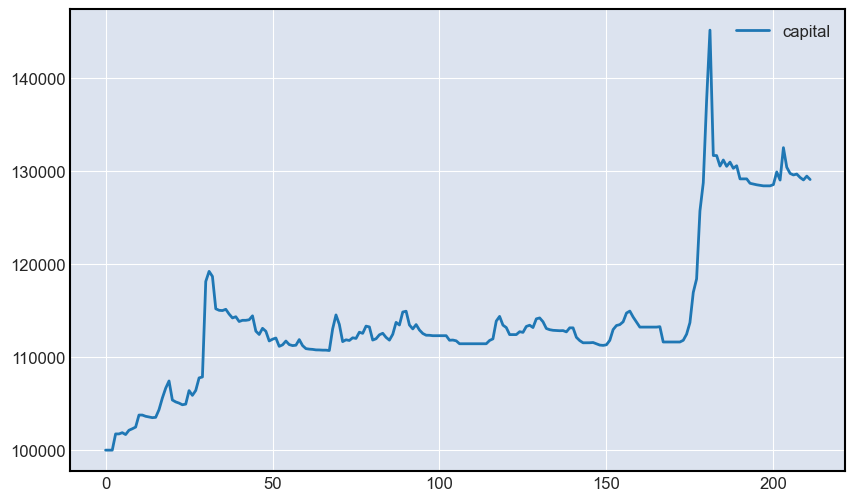

In [192]:
plt.figure(figsize=(10,6))
plt.plot(df4['capital'],label='capital')
plt.legend()
plt.show() #将资产值可视化

可以发现，用LSTM模型实施自动化交易，总收益率可以多3-5%，而且在面对下跌行情的时候更加稳健，但是会不可避免地存在一定的滞后性问题

# 3.扩充因子后的LSTM预测

In [83]:
df5 = ts_pro.daily(ts_code='000001.SZ',
                   start_date = '20150101',
                   end_date ='20241129')
df5 = pd.DataFrame(df5)
df5 = df5.reindex(index=df5.index[::-1])
df5 = df5.reset_index(drop=True)
print(df5) #获取日线行情

        ts_code trade_date   open   high    low  close  pre_close  change  \
0     000001.SZ   20150105  15.99  16.28  15.60  16.02      15.84    0.18   
1     000001.SZ   20150106  15.85  16.39  15.55  15.78      16.02   -0.24   
2     000001.SZ   20150107  15.56  15.83  15.30  15.48      15.78   -0.30   
3     000001.SZ   20150108  15.50  15.57  14.90  14.96      15.48   -0.52   
4     000001.SZ   20150109  14.90  15.87  14.71  15.08      14.96    0.12   
...         ...        ...    ...    ...    ...    ...        ...     ...   
2404  000001.SZ   20241125  11.28  11.34  11.14  11.18      11.28   -0.10   
2405  000001.SZ   20241126  11.18  11.31  11.14  11.27      11.18    0.09   
2406  000001.SZ   20241127  11.24  11.39  11.15  11.39      11.27    0.12   
2407  000001.SZ   20241128  11.39  11.42  11.32  11.34      11.39   -0.05   
2408  000001.SZ   20241129  11.37  11.46  11.34  11.38      11.34    0.04   

      pct_chg         vol        amount  
0      1.1400  2860436.43  4.5653

In [84]:
df5['SMA_50'] = df5['close'].rolling(window=50).mean()
df5['SMA_200'] = df5['close'].rolling(window=200).mean()

# 相对强弱指标（RSI）
delta = df5['close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
average_gain = gain.rolling(window=14).mean()
average_loss = loss.rolling(window=14).mean()
rs = average_gain / average_loss
df5['RSI'] = 100 - (100 / (1 + rs))

# 移动平均收敛/发散（MACD）
df5['EMA_12'] = df5['close'].ewm(span=12, adjust=False).mean()
df5['EMA_26'] = df5['close'].ewm(span=26, adjust=False).mean()
df5['MACD'] = df5['EMA_12'] - df5['EMA_26']

# 删除缺失值
df5 = df5.dropna()
df5 = df5.drop(columns=['open', 'high', 'low', 'pre_close', 'change' ,'pct_chg'])
df5.reset_index()
df5

,ts_code,trade_date,close,vol,amount,SMA_50,SMA_200,RSI,EMA_12,EMA_26,MACD
199,000001.SZ,20151030,11.36,535930.72,6.079810e+05,11.1306,13.95980,54.887218,11.281255,11.205911,0.075343
200,000001.SZ,20151102,11.14,484435.81,5.440002e+05,11.1020,13.93540,50.344828,11.259523,11.201029,0.058494
201,000001.SZ,20151103,11.05,391265.18,4.348188e+05,11.0702,13.91175,52.517986,11.227289,11.189842,0.037447
202,000001.SZ,20151104,11.69,1307244.19,1.493256e+06,11.0532,13.89280,64.130435,11.298475,11.226890,0.071585
203,000001.SZ,20151105,12.07,2292189.80,2.780267e+06,11.0492,13.87835,69.444444,11.417171,11.289343,0.127828
...,...,...,...,...,...,...,...,...,...,...,...
2404,000001.SZ,20241125,11.18,1166020.32,1.310131e+06,11.2738,10.60855,37.948718,11.504887,11.501555,0.003332
2405,000001.SZ,20241126,11.27,831078.20,9.337339e+05,11.2976,10.61825,42.783505,11.468751,11.484403,-0.015653
2406,000001.SZ,20241127,11.39,895178.05,1.010002e+06,11.3284,10.62770,34.705882,11.456635,11.477410,-0.020775
2407,000001.SZ,20241128,11.34,733168.54,8.331213e+05,11.3572,10.63630,37.820513,11.438691,11.467232,-0.028541


In [85]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [86]:
features = ['vol', 'amount', 'SMA_50', 'SMA_200', 'RSI', 'EMA_12', 'EMA_26', 'MACD']
X = df5[features]
df5['Price_change'] = df5['close'].pct_change().shift(-1)  # 次日的股价变动
Y = (df5['Price_change'] > 0).astype(int)  # 如果涨则为1，否则为0
X = X.dropna()
Y = Y.dropna()
transfer = MinMaxScaler(feature_range=(0, 10)) 
X = transfer.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [87]:
RFmodel = RandomForestClassifier(n_estimators=100, random_state=42)
RFmodel.fit(X_train, Y_train)
Y_pred = RFmodel.predict(X_test)
print(f"Accuracy: {accuracy_score(Y_test, Y_pred)}")
print(classification_report(Y_test, Y_pred))

Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.54      0.58      0.56       241
           1       0.45      0.41      0.43       201

    accuracy                           0.50       442
   macro avg       0.49      0.49      0.49       442
weighted avg       0.50      0.50      0.50       442



## 3.1随机森林模型筛选因子

In [88]:
#对各个因子进行评分,筛选因子
importances = RFmodel.feature_importances_
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
print(importance_df)

   Feature  Importance
4      RSI    0.134270
7     MACD    0.128313
0      vol    0.127548
3  SMA_200    0.125562
1   amount    0.125266
2   SMA_50    0.121897
5   EMA_12    0.119888
6   EMA_26    0.117255


0.13427033529423524 RSI
0.1283134677206733 MACD
0.12754814918072127 vol
0.12556193055043166 SMA_200
0.12526582033885925 amount
0.12189700125883636 SMA_50
0.11988790988515584 EMA_12
0.11725538577108713 EMA_26


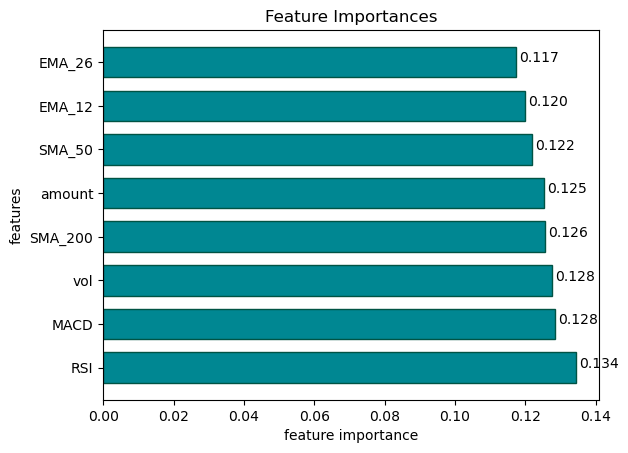

In [137]:
plt.barh(importance_df['Feature'], importance_df['Importance'], height=0.7, color='#008792', edgecolor='#005344')
plt.xlabel('feature importance')
plt.ylabel('features')
plt.title('Feature Importances')
for a,b in zip( importance_df['Importance'],importance_df['Feature']):
   print(a,b)
   plt.text(a+0.001, b,'%.3f'%float(a))
plt.show()

In [90]:
df5.drop(columns=['EMA_12', 'EMA_26', 'SMA_50', 'amount', 'SMA_200', 'Price_change'], inplace=True)
df5

,ts_code,trade_date,close,vol,RSI,MACD
199,000001.SZ,20151030,11.36,535930.72,54.887218,0.075343
200,000001.SZ,20151102,11.14,484435.81,50.344828,0.058494
201,000001.SZ,20151103,11.05,391265.18,52.517986,0.037447
202,000001.SZ,20151104,11.69,1307244.19,64.130435,0.071585
203,000001.SZ,20151105,12.07,2292189.80,69.444444,0.127828
...,...,...,...,...,...,...
2404,000001.SZ,20241125,11.18,1166020.32,37.948718,0.003332
2405,000001.SZ,20241126,11.27,831078.20,42.783505,-0.015653
2406,000001.SZ,20241127,11.39,895178.05,34.705882,-0.020775
2407,000001.SZ,20241128,11.34,733168.54,37.820513,-0.028541


In [91]:
x = []
y = []
win_len = 10

for i in range(len(df5)-win_len-1):
    x.append(df5.iloc[i:i + win_len , 2:6].to_numpy().flatten())
    y.append(df5.iloc[i + win_len , 2])
    
transfer = MinMaxScaler(feature_range=(0, 10)) 
x = np.array(x)
x = transfer.fit_transform(x)
y = np.array(y)

x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.2)

In [92]:
new_model = Sequential()
new_model.add(LSTM(units=64, return_sequences=True, input_shape=(x_train.shape[1], 1)))
new_model.add(Dropout(0.2))
new_model.add(LSTM(units=32, return_sequences=False))
new_model.add(Dropout(0.2))
new_model.add(Dense(units=1))
new_model.compile(optimizer='adam', loss='mean_squared_error')
new_model.summary()

C:\Users\13750\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 40, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 40, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
new_history = new_model.fit(x_train, y_train, batch_size=72, epochs=200, validation_data=(x_valid,y_valid),validation_freq=1)

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


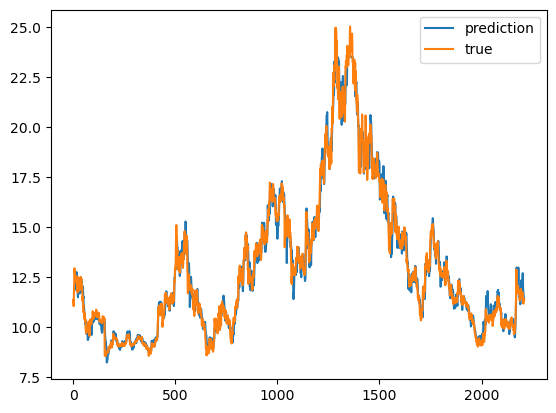

In [94]:
prediction = new_model.predict(x)
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(range(10, 10+len(prediction)), prediction)
ax.plot(range(len(df5)), df5['close'])
ax.legend(['prediction','true'])
plt.show()

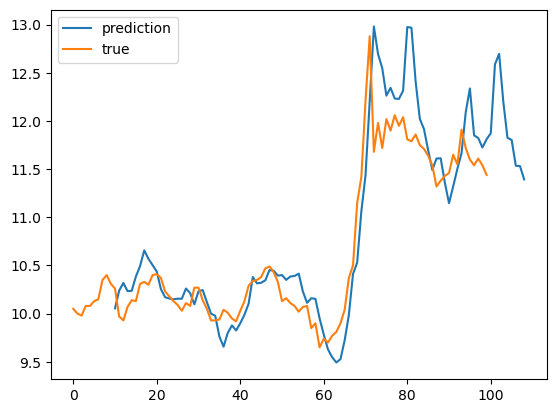

In [95]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(range(10, 10+len(prediction[2100:2200])), prediction[2100:2200])
ax.plot(range(len(df5.iloc[2100:2200,2])), df5.iloc[2100:2200,2])
ax.legend(['prediction','true'])
plt.show()

可以看出，该模型虽然在预测精度上有所欠缺，但是在某些时刻能够提前预判股票的上涨和下跌，比如图中10-20、80-90处，能够在一定程度上缓解了滞后性的问题

## 3.2 PCA探索因子

In [169]:
from sklearn.decomposition import PCA

In [164]:
df6 = df5.set_index('trade_date')
df6

,ts_code,close,vol,amount,SMA_50,SMA_200,RSI,EMA_12,EMA_26,MACD
trade_date,,,,,,,,,,
20151030,000001.SZ,11.36,535930.72,6.079810e+05,11.1306,13.95980,54.887218,11.281255,11.205911,0.075343
20151102,000001.SZ,11.14,484435.81,5.440002e+05,11.1020,13.93540,50.344828,11.259523,11.201029,0.058494
20151103,000001.SZ,11.05,391265.18,4.348188e+05,11.0702,13.91175,52.517986,11.227289,11.189842,0.037447
20151104,000001.SZ,11.69,1307244.19,1.493256e+06,11.0532,13.89280,64.130435,11.298475,11.226890,0.071585
20151105,000001.SZ,12.07,2292189.80,2.780267e+06,11.0492,13.87835,69.444444,11.417171,11.289343,0.127828
...,...,...,...,...,...,...,...,...,...,...
20241125,000001.SZ,11.18,1166020.32,1.310131e+06,11.2738,10.60855,37.948718,11.504887,11.501555,0.003332
20241126,000001.SZ,11.27,831078.20,9.337339e+05,11.2976,10.61825,42.783505,11.468751,11.484403,-0.015653
20241127,000001.SZ,11.39,895178.05,1.010002e+06,11.3284,10.62770,34.705882,11.456635,11.477410,-0.020775


In [165]:
feature = df6[['vol','amount','SMA_50','SMA_200','RSI','EMA_12','EMA_26','MACD']]

In [167]:
sc_feature = transfer.fit_transform(feature)

In [170]:
pca = PCA(n_components=8)
pca.fit(sc_feature)
print(pca.explained_variance_ratio_)

[7.10159219e-01 1.64878941e-01 5.98758168e-02 4.86261355e-02
 1.53112329e-02 8.75454193e-04 2.73200726e-04 9.44385071e-33]


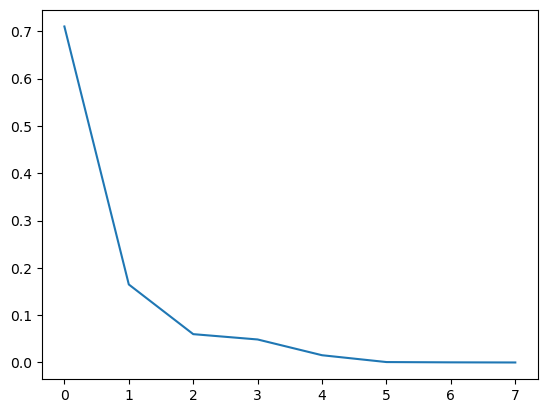

In [171]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)
plt.show()

可视化主成分方差贡献率，选择前三个主成分

In [172]:
sc_feature_pca = pca.transform(sc_feature)

In [176]:
pca_data = pd.DataFrame(sc_feature_pca[:,0:3])

In [193]:
df7 = df6.reset_index(drop=True)

In [197]:
df8 = pd.concat([df7,pca_data], axis=1)

In [198]:
df8

,ts_code,close,0,1,2
0,000001.SZ,11.36,2.246528,4.063510,1.609724
1,000001.SZ,11.14,2.232327,3.739464,1.643867
2,000001.SZ,11.05,2.202153,3.804658,1.441318
3,000001.SZ,11.69,2.289232,5.030939,2.658488
4,000001.SZ,12.07,2.417480,5.962305,4.241046
...,...,...,...,...,...
2205,000001.SZ,11.18,1.691856,3.604323,3.007205
2206,000001.SZ,11.27,1.650446,3.711597,2.339983
2207,000001.SZ,11.39,1.672452,3.238251,2.656482
2208,000001.SZ,11.34,1.655367,3.340108,2.316634


In [200]:
x = []
y = []
win_len = 10

for i in range(len(df8)-win_len-1):
    x.append(df8.iloc[i:i + win_len , 1:5].to_numpy().flatten())
    y.append(df8.iloc[i + win_len , 1])
    
x = np.array(x)
y = np.array(y)

x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.2)

In [201]:
pca_model = Sequential()
pca_model.add(LSTM(units=64, return_sequences=True, input_shape=(x_train.shape[1], 1)))
pca_model.add(Dropout(0.2))
pca_model.add(LSTM(units=32, return_sequences=False))
pca_model.add(Dropout(0.2))
pca_model.add(Dense(units=1))
pca_model.compile(optimizer='adam', loss='mean_squared_error')
pca_model.summary()

C:\Users\13750\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                  │ (None, 40, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 40, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
pca_history = pca_model.fit(x_train, y_train, batch_size=72, epochs=200, validation_data=(x_valid,y_valid),validation_freq=1)

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


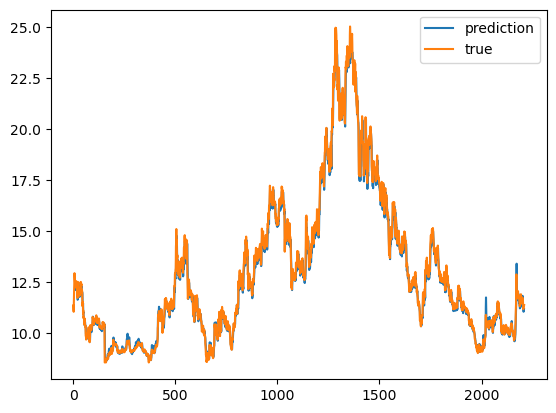

In [203]:
pca_prediction = pca_model.predict(x)
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(range(10, 10+len(pca_prediction)), pca_prediction)
ax.plot(range(len(df8)), df8['close'])
ax.legend(['prediction','true'])
plt.show()

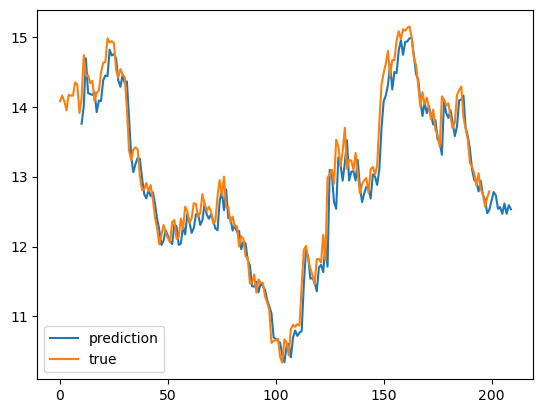

In [204]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(range(10, 10+len(pca_prediction[1600:1800])), pca_prediction[1600:1800])
ax.plot(range(len(df8.iloc[1600:1800,1])), df8.iloc[1600:1800,1])
ax.legend(['prediction','true'])
plt.show()

综合上述训练的三种LSTM模型来看，经过PCA处理后的数据得到的LSTM在预测误差上最优，loss值可达到0.08，但是存在明显的滞后性，经过随机森林选择因子后训练得到的LSTM虽然在某些时候能够避免滞后，但是预测误差却最大，loss达到了0.20，最后，仅依赖时间序列训练得到的模型loss值为0.14，同时也存在滞后性

# 4.配对交易(白银期货)

配对交易是一种能够不受市场波动影响的交易策略，主要针对两个具有高度相关性和协整性的期货或者股票，在两个股票的价格差值超过他们的差值正常波动区间的时，买入被低估的股票，融券卖出被高估的股票，等到两者差值回归至正常水平时，再卖出一开始买入的股票，归还之前融券卖出的股票，从而成功套利

In [111]:
import time

In [112]:
ts.set_token('d6e543707c857531cec5a2e37c157b09b9cd1d29b7bce8fae8cba43f')
ts_pro = ts.pro_api()

In [113]:
ids = ['AG2502', 'AG2504', 'AG2506', 'AG2501', 'AG2503']
start_date = '20241120'
end_date = '20241201'
all_df = pd.DataFrame()

In [114]:
for id in ids:
    ts_code = id +'.SHF'
    df = ts.pro_bar(ts_code = ts_code, start_date = start_date, end_date = end_date, asset='FT', freq = '5min')
    df = df.reindex(index=df.index[::-1])
    df = df[['trade_time', 'close']]
    df.columns = ['trade_time', id]
    df = df.set_index('trade_time')
    all_df = pd.concat((all_df, df), axis= 1)
    time.sleep(62)

In [115]:
all_df

,AG2502,AG2504,AG2506,AG2501,AG2503
trade_time,,,,,
2024-11-20 00:00:00,7766.0,7790.0,7813.0,7755.0,7779.0
2024-11-20 00:05:00,7763.0,7786.0,7811.0,7753.0,7775.0
2024-11-20 00:10:00,7772.0,7794.0,7818.0,7758.0,7784.0
2024-11-20 00:15:00,7771.0,7795.0,7818.0,7761.0,7783.0
2024-11-20 00:20:00,7782.0,7804.0,7829.0,7770.0,7793.0
...,...,...,...,...,...
2024-11-30 02:10:00,7698.0,7724.0,7748.0,7682.0,7710.0
2024-11-30 02:15:00,7697.0,7723.0,7750.0,7685.0,7713.0
2024-11-30 02:20:00,7694.0,7718.0,7744.0,7679.0,7705.0


In [123]:
all_df.to_csv('./AGdata.csv')

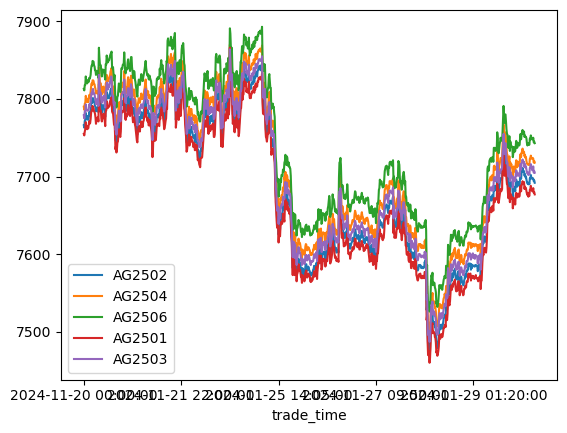

In [116]:
all_df.plot()
plt.show()

In [117]:
import seaborn as sns

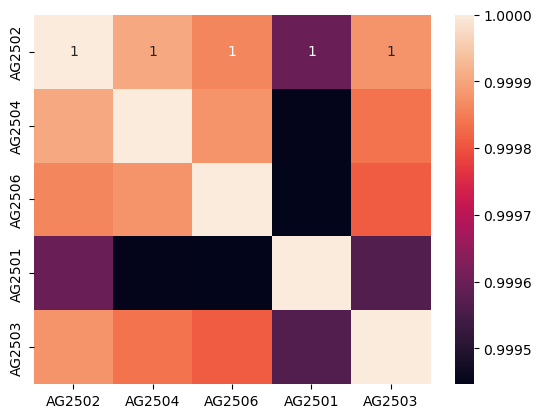

In [118]:
sns.heatmap(all_df.corr(), annot=True)
plt.show()

### 选择AG2502和AG2504做配对交易

In [120]:
from statsmodels.tsa.api import adfuller

In [122]:
print(adfuller(all_df['AG2502']))
print(adfuller(all_df['AG2504']))

(-1.6136531547667186, 0.4760582339828322, 1, 925, {'1%': -3.437439232284603, '5%': -2.8646696476686477, '10%': -2.5684364181154127}, 6553.864144889629)
(-1.6153709553476503, 0.47515694743962283, 1, 925, {'1%': -3.437439232284603, '5%': -2.8646696476686477, '10%': -2.5684364181154127}, 6503.309363164204)


p-value约为0.47，不平稳

In [124]:
print(adfuller(np.diff(all_df['AG2502'])))
print(adfuller(np.diff(all_df['AG2504'])))

(-28.899814252366173, 0.0, 0, 925, {'1%': -3.437439232284603, '5%': -2.8646696476686477, '10%': -2.5684364181154127}, 6548.616404282616)
(-28.33157917769732, 0.0, 0, 925, {'1%': -3.437439232284603, '5%': -2.8646696476686477, '10%': -2.5684364181154127}, 6498.122459402156)


一阶差分后平稳

In [126]:
from statsmodels.tsa.api import coint
print(coint(all_df['AG2502'], all_df['AG2504']))

(-5.142702408828742, 8.92230131349782e-05, array([-3.90830621, -3.34273634, -3.0490333 ]))


p-value < 0.05 通过协整性检验

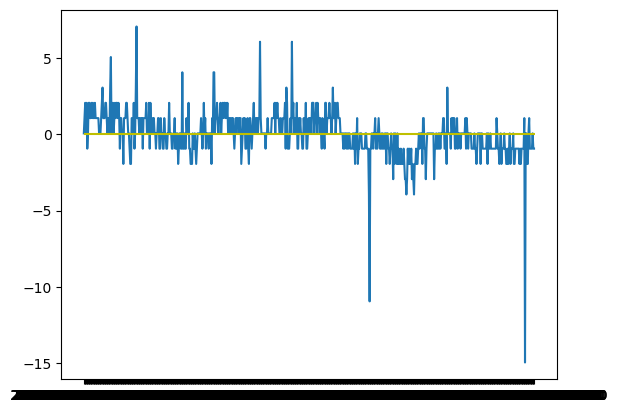

In [145]:
price_A = all_df['AG2502'][:650]
price_B = all_df['AG2504'][:650]

cmp = price_A - price_B
nocenter_cmp = cmp - cmp.mean()

fig = plt.figure()
plt.plot(nocenter_cmp)
plt.hlines(0, 0, len(nocenter_cmp), colors = 'y')
plt.show()

计算去中心化价差

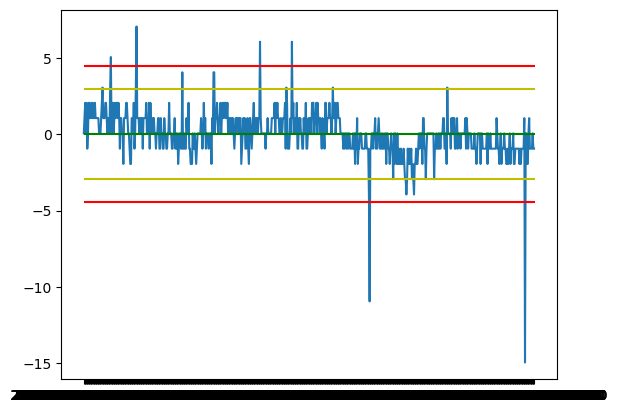

In [134]:
sigma = nocenter_cmp.std()
fig = plt.figure()
plt.plot(nocenter_cmp)
plt.hlines(0, 0, len(nocenter_cmp), colors = 'g')
plt.hlines(2*sigma, 0, len(nocenter_cmp), color='y')
plt.hlines(-2*sigma, 0, len(nocenter_cmp), color='y')
plt.hlines(3*sigma, 0, len(nocenter_cmp), color='r')
plt.hlines(-3*sigma, 0, len(nocenter_cmp), color='r')
plt.show()

In [146]:
price_A = price_A.values
price_B = price_B.values
cmp = price_A - price_B
nocenter_cmp = cmp - np.mean(cmp)

sigma = np.std(nocenter_cmp)
open = 2*sigma
stop = 3*sigma

total_profit = []
current_profit = 0
hold = False
position = 0

hold_priceA = 0
hold_priceB = 0

In [147]:
for i in range(len(price_A)):
    if hold == False:
        if nocenter_cmp[i] >= open:
            hold_priceA = price_A[i]
            hold_priceB = price_B[i]
            position = -1
            hold = True              
            print("A被高估，B被低估，买入B，融券卖出A")               
        elif nocenter_cmp[i] <= -open:
            hold_priceA = price_A[i]
            hold_priceB = price_B[i]
            position = 1
            hold = True              
            print("A被低估，B被高估，买入A，融券卖出B")
    else:
        
        if nocenter_cmp[i] <= 0 and position == -1:
            profit = (hold_priceA - price_A[i]) + (price_B[i] - hold_priceB)
            current_profit += profit
            position = 0
            hold = False
            print("价格回归，卖出B，归还A，结算本笔交易收益为",profit)
        if nocenter_cmp[i] >= 0 and position == 1:
            profit = (price_A[i] - hold_priceA) + (hold_priceB - price_B[i])
            current_profit += profit
            position = 0
            hold = False
            print("价格回归，卖出A，归还B，结算本笔交易收益为",profit)
    total_profit.append(current_profit)

A被高估，B被低估，买入B，融券卖出A
价格回归，卖出B，归还A，结算本笔交易收益为 4.0
A被高估，B被低估，买入B，融券卖出A
价格回归，卖出B，归还A，结算本笔交易收益为 4.0
A被高估，B被低估，买入B，融券卖出A
价格回归，卖出B，归还A，结算本笔交易收益为 5.0
A被高估，B被低估，买入B，融券卖出A
价格回归，卖出B，归还A，结算本笔交易收益为 5.0
A被高估，B被低估，买入B，融券卖出A
价格回归，卖出B，归还A，结算本笔交易收益为 7.0
A被高估，B被低估，买入B，融券卖出A
价格回归，卖出B，归还A，结算本笔交易收益为 4.0
A被高估，B被低估，买入B，融券卖出A
价格回归，卖出B，归还A，结算本笔交易收益为 7.0
A被高估，B被低估，买入B，融券卖出A
价格回归，卖出B，归还A，结算本笔交易收益为 4.0
A被低估，B被高估，买入A，融券卖出B
价格回归，卖出A，归还B，结算本笔交易收益为 4.0
A被低估，B被高估，买入A，融券卖出B
价格回归，卖出A，归还B，结算本笔交易收益为 4.0
A被高估，B被低估，买入B，融券卖出A
价格回归，卖出B，归还A，结算本笔交易收益为 4.0
A被低估，B被高估，买入A，融券卖出B
价格回归，卖出A，归还B，结算本笔交易收益为 15.0


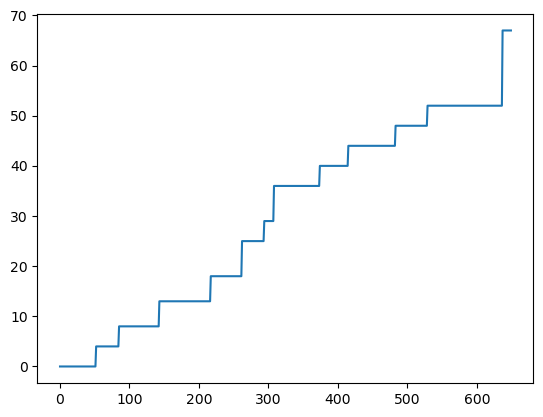

In [148]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(range(len(total_profit)), total_profit)
plt.show()